In [27]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import os

In [28]:
file_path = "data/autoscout24-germany-dataset.csv"

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully")
except Exception as e:
    print(f"Error loading dataset: {e}")    

Dataset loaded successfully


In [29]:
print("Shape: ", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape:  (46405, 9)

Columns:
 ['mileage', 'make', 'model', 'fuel', 'gear', 'offerType', 'price', 'hp', 'year']


In [30]:
df.head()

,mileage,make,model,fuel,gear,offerType,price,hp,year
0,235000,BMW,316,Diesel,Manual,Used,6800,116.0,2011
1,92800,Volkswagen,Golf,Gasoline,Manual,Used,6877,122.0,2011
2,149300,SEAT,Exeo,Gasoline,Manual,Used,6900,160.0,2011
3,96200,Renault,Megane,Gasoline,Manual,Used,6950,110.0,2011
4,156000,Peugeot,308,Gasoline,Manual,Used,6950,156.0,2011


In [31]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count" : missing_values,
    "Missing%" : missing_percentage

})

missing_df

,Missing Count,Missing%
mileage,0,0.00
make,0,0.00
model,143,0.31
fuel,0,0.00
gear,182,0.39
offerType,0,0.00
price,0,0.00
hp,29,0.06
year,0,0.00


In [32]:
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

Duplicate rows: 2140


In [33]:
df.describe()

,mileage,price,hp,year
count,4.640500e+04,4.640500e+04,46376.000000,46405.000000
mean,7.117786e+04,1.657234e+04,132.990987,2016.012951
std,6.262531e+04,1.930470e+04,75.449284,3.155214
min,0.000000e+00,1.100000e+03,1.000000,2011.000000
25%,1.980000e+04,7.490000e+03,86.000000,2013.000000
50%,6.000000e+04,1.099900e+04,116.000000,2016.000000
75%,1.050000e+05,1.949000e+04,150.000000,2019.000000
max,1.111111e+06,1.199900e+06,850.000000,2021.000000


In [34]:
summary = {
    "rows" : int(df.shape[0]),
    "columns" : int(df.shape[1]),
    "column_names" : df.columns.tolist(),
    "dtypes" : {col : str(dtype) for col, dtype in df.dtypes.items()},
    "missing_values" : missing_values.to_dict(),
    "missing_percentage" : missing_percentage.to_dict(),
    "duplicate_rows" : int(duplicate_rows)
}
summary

{'rows': 46405,
 'columns': 9,
 'column_names': ['mileage',
  'make',
  'model',
  'fuel',
  'gear',
  'offerType',
  'price',
  'hp',
  'year'],
 'dtypes': {'mileage': 'int64',
  'make': 'object',
  'model': 'object',
  'fuel': 'object',
  'gear': 'object',
  'offerType': 'object',
  'price': 'int64',
  'hp': 'float64',
  'year': 'int64'},
 'missing_values': {'mileage': 0,
  'make': 0,
  'model': 143,
  'fuel': 0,
  'gear': 182,
  'offerType': 0,
  'price': 0,
  'hp': 29,
  'year': 0},
 'missing_percentage': {'mileage': 0.0,
  'make': 0.0,
  'model': 0.31,
  'fuel': 0.0,
  'gear': 0.39,
  'offerType': 0.0,
  'price': 0.0,
  'hp': 0.06,
  'year': 0.0},
 'duplicate_rows': 2140}

In [36]:


output_path = "outputs/inspection_summary.json"

os.makedirs("outputs", exist_ok=True)

with open(output_path, "w") as f:
    json.dump(summary, f, indent=4)

print("Summary saved.")

Summary saved.


In [37]:
df_raw = df.copy()
df_clean = df.copy()

In [43]:
df_raw = df.copy()
df_clean = df.copy()

# Check current object type and shape
print("Type of df_clean:", type(df_clean))
print("Initial shape:", df_clean.shape)

# Duplicate analysis
before_rows = df_clean.shape[0]
duplicate_rows = df_clean.duplicated().sum()

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Shape after cleaning
after_rows = df_clean.shape[0]

# Print results
print("Rows before:", before_rows)
print("Duplicate rows removed:", duplicate_rows)
print("Rows after:", after_rows)

Type of df_clean: <class 'pandas.core.frame.DataFrame'>
Initial shape: (46405, 9)
Rows before: 46405
Duplicate rows removed: 2140
Rows after: 44265


In [44]:
df_clean.columns.tolist()

['mileage',
 'make',
 'model',
 'fuel',
 'gear',
 'offerType',
 'price',
 'hp',
 'year']

In [45]:
df_clean.dtypes

mileage        int64
make          object
model         object
fuel          object
gear          object
offerType     object
price          int64
hp           float64
year           int64
dtype: object

In [46]:
df_clean.head()

,mileage,make,model,fuel,gear,offerType,price,hp,year
0,235000,BMW,316,Diesel,Manual,Used,6800,116.0,2011
1,92800,Volkswagen,Golf,Gasoline,Manual,Used,6877,122.0,2011
2,149300,SEAT,Exeo,Gasoline,Manual,Used,6900,160.0,2011
3,96200,Renault,Megane,Gasoline,Manual,Used,6950,110.0,2011
4,156000,Peugeot,308,Gasoline,Manual,Used,6950,156.0,2011


In [48]:
missing_values_clean = df_clean.isnull().sum()
missing_percentage_clean = (df_clean.isnull().mean()*100).round(2)

missing_df_clean = pd.DataFrame(
    {
        "Missing Count": missing_values_clean,
        "Missing Percentage": missing_percentage_clean
    }
).sort_values(by = "Missing Percentage", ascending=False)

missing_df_clean

,Missing Count,Missing Percentage
gear,175,0.40
model,137,0.31
hp,24,0.05
mileage,0,0.00
make,0,0.00
fuel,0,0.00
offerType,0,0.00
price,0,0.00
year,0,0.00


In [49]:
#Validation Check. To check weird values

invalid_mileage = (df_clean["mileage"]<0).sum() if "mileage" in df_clean.columns else 0
zero_mileage = (df_clean["mileage"] == 0).sum() if "mileage" in df_clean.columns else 0

invalid_price = (df_clean["price"]<=0).sum() if "price" in df_clean.columns else 0
very_low_price = (df_clean["price"] < 500).sum() if "price" in df_clean.columns else 0

invalid_hp = (df_clean["hp"]<=0).sum() if "hp" in df_clean.columns else 0

print("Invalid mileage (<0):", invalid_mileage)
print("Zero mileage:", zero_mileage)
print("Invalid price (<=0):", invalid_price)
print("Very low price (<500):", very_low_price)
print("Invalid hp (<=0):", invalid_hp)


Invalid mileage (<0): 0
Zero mileage: 63
Invalid price (<=0): 0
Very low price (<500): 0
Invalid hp (<=0): 0


In [50]:
if "mileage" in df_clean.columns:
    df_clean = df_clean[df_clean["mileage"] >= 0]

if "price" in df_clean.columns:
    df_clean = df_clean[df_clean["price"] > 0]

if "hp" in df_clean.columns:
    df_clean = df_clean[df_clean["hp"] > 0]

In [51]:
cleaning_summary = {
    "original_rows": int(df_raw.shape[0]),
    "after_duplicate_removal": int(after_rows),
    "final_rows_after_cleaning": int(df_clean.shape[0]),
    "duplicates_removed": int(duplicate_rows),
}

cleaning_summary

{'original_rows': 46405,
 'after_duplicate_removal': 44265,
 'final_rows_after_cleaning': 44241,
 'duplicates_removed': 2140}

In [52]:
cleaned_output_path = "outputs/cleaned_cars_dataset.csv"
df_clean.to_csv(cleaned_output_path, index=False)

print("Cleaned dataset saved.")

Cleaned dataset saved.


In [53]:
missing_df_clean

,Missing Count,Missing Percentage
gear,175,0.40
model,137,0.31
hp,24,0.05
mileage,0,0.00
make,0,0.00
fuel,0,0.00
offerType,0,0.00
price,0,0.00
year,0,0.00


In [54]:
df_clean.loc[df_clean["mileage"] == 0, "mileage"] = np.nan

In [55]:
df_clean["hp"].fillna(df_clean["hp"].median(), inplace=True)

df_clean.drop(columns=["gear"], inplace=True)

df_clean["model"].fillna("Unknown", inplace=True)

In [56]:
missing_df_clean

,Missing Count,Missing Percentage
gear,175,0.40
model,137,0.31
hp,24,0.05
mileage,0,0.00
make,0,0.00
fuel,0,0.00
offerType,0,0.00
price,0,0.00
year,0,0.00


In [57]:
import numpy as np

df_clean.loc[df_clean["mileage"] == 0, "mileage"] = np.nan
df_clean["mileage"].fillna(df_clean["mileage"].median(), inplace=True)

In [58]:
df_clean["hp"].fillna(df_clean["hp"].median(), inplace=True)

In [59]:
df_clean["model"].fillna("Unknown", inplace=True)

In [61]:
df_clean.columns.tolist()

['mileage', 'make', 'model', 'fuel', 'offerType', 'price', 'hp', 'year']

In [ ]:
#data is finally cleaned

missing_values_clean = df_clean.isnull().sum()
missing_percentage_clean = (missing_values_clean / len(df_clean)) * 100

missing_df_clean = pd.DataFrame({
    "Missing Count": missing_values_clean,
    "Missing %": missing_percentage_clean.round(2)
}).sort_values(by="Missing %", ascending=False)

missing_df_clean

,Missing Count,Missing %
mileage,0,0.0
make,0,0.0
model,0,0.0
fuel,0,0.0
offerType,0,0.0
price,0,0.0
hp,0,0.0
year,0,0.0


In [64]:
df_clean.describe()

,mileage,price,hp,year
count,4.424100e+04,4.424100e+04,44241.000000,44241.000000
mean,7.233255e+04,1.655382e+04,133.609209,2015.932122
std,6.212191e+04,1.946113e+04,75.380845,3.119679
min,1.000000e+00,1.100000e+03,1.000000,2011.000000
25%,2.168200e+04,7.490000e+03,86.000000,2013.000000
50%,6.132000e+04,1.099000e+04,116.000000,2016.000000
75%,1.060000e+05,1.949000e+04,150.000000,2019.000000
max,1.111111e+06,1.199900e+06,850.000000,2021.000000


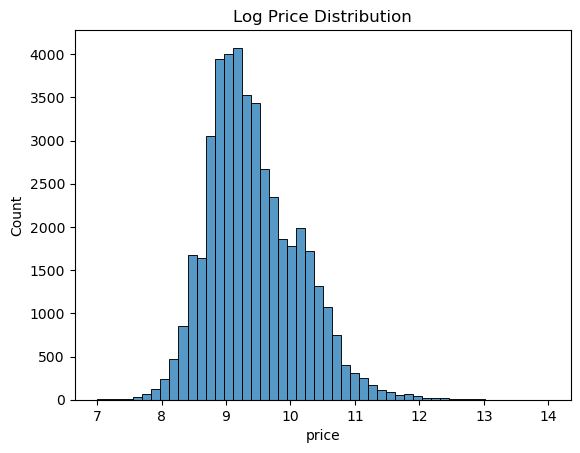

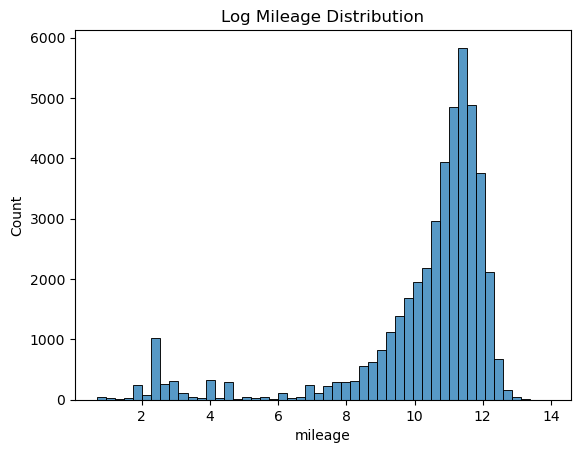

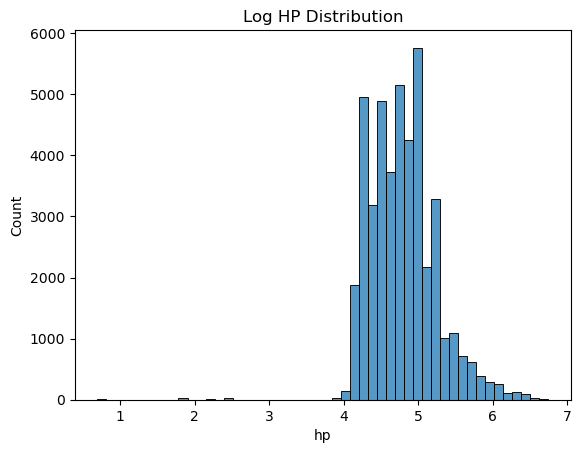

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

sns.histplot(np.log1p(df_clean["price"]), bins=50)
plt.title("Log Price Distribution")
plt.show()
sns.histplot(np.log1p(df_clean["mileage"]), bins=50)
plt.title("Log Mileage Distribution")
plt.show()

sns.histplot(np.log1p(df_clean["hp"]), bins=50)
plt.title("Log HP Distribution")
plt.show()

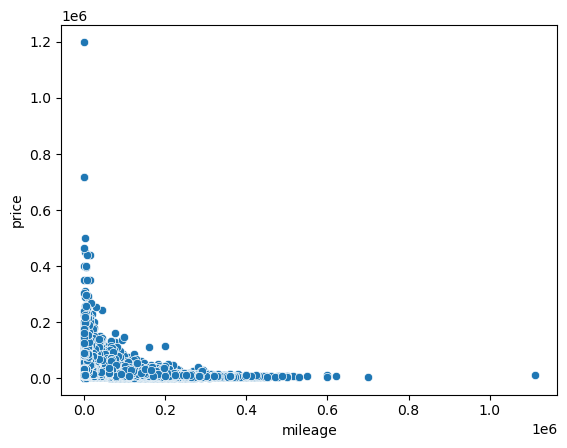

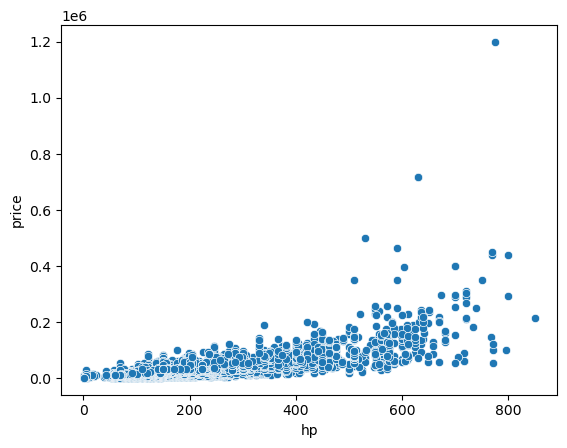

In [73]:
sns.scatterplot(x="mileage", y="price", data=df_clean)
plt.show()

sns.scatterplot(x="hp", y="price", data=df_clean)
plt.show()

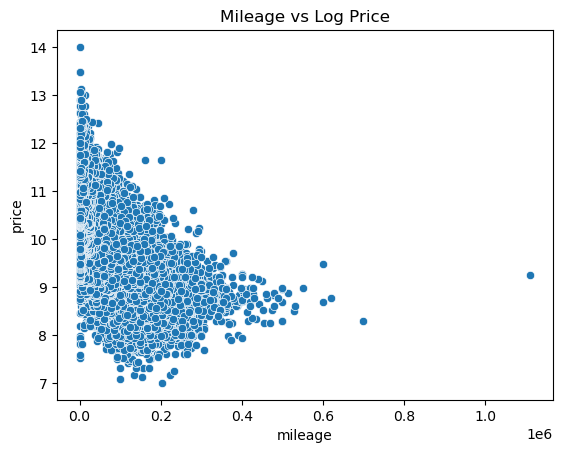

In [74]:
import numpy as np

sns.scatterplot(x="mileage", y=np.log1p(df_clean["price"]), data=df_clean)
plt.title("Mileage vs Log Price")
plt.show()

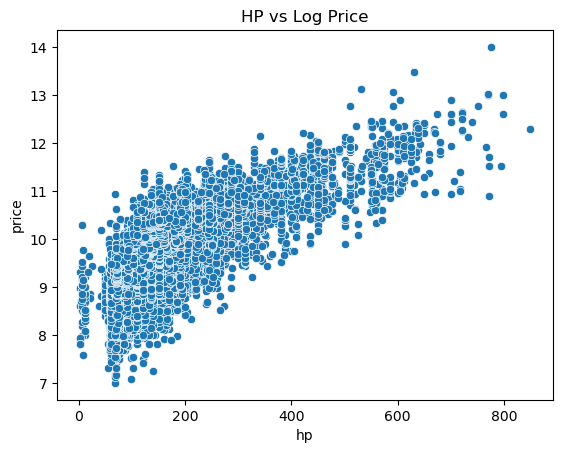

In [75]:
sns.scatterplot(x="hp", y=np.log1p(df_clean["price"]), data=df_clean)
plt.title("HP vs Log Price")
plt.show()


In [ ]:
#EDA Done

df_clean["log_price"] = np.log1p(df_clean["price"])

df_clean[["log_price", "mileage", "hp", "year"]].corr()

,log_price,mileage,hp,year
log_price,1.000000,-0.473240,0.729955,0.671520
mileage,-0.473240,1.000000,-0.023177,-0.668702
hp,0.729955,-0.023177,1.000000,0.181901
year,0.671520,-0.668702,0.181901,1.000000


In [77]:
df_clean.head()

,mileage,make,model,fuel,offerType,price,hp,year,log_price
0,235000.0,BMW,316,Diesel,Used,6800,116.0,2011,8.824825
1,92800.0,Volkswagen,Golf,Gasoline,Used,6877,122.0,2011,8.836083
2,149300.0,SEAT,Exeo,Gasoline,Used,6900,160.0,2011,8.839422
3,96200.0,Renault,Megane,Gasoline,Used,6950,110.0,2011,8.846641
4,156000.0,Peugeot,308,Gasoline,Used,6950,156.0,2011,8.846641
